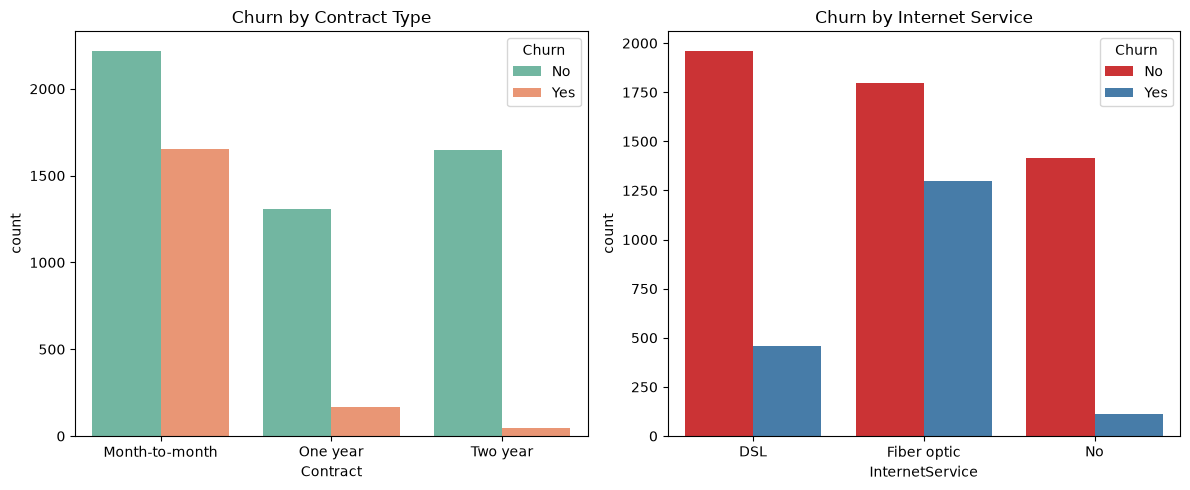

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/cleaned_churn_data.csv')

plt.figure(figsize=(12, 5))

# Plot 1: Churn by Contract
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')

# Plot 2: Churn by Internet Service
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1')
plt.title('Churn by Internet Service')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Select feature subset for driver analysis
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'is_high_risk']
X = pd.get_dummies(df[['Contract', 'InternetService', 'PaymentMethod', 'TechSupport'] + features], drop_first=True)
y = df['churn_numeric']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance series
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 5 Drivers of Churn:")
print(importance.head(5))

Top 5 Drivers of Churn:
TotalCharges                   0.288884
MonthlyCharges                 0.267042
tenure                         0.200497
is_high_risk                   0.081634
InternetService_Fiber optic    0.044085
dtype: float64
